**Imports**

# **Fragment Length Frequency and Rescaling**

**Read query.bed.gz File**               
We load the compressed BED file containing mapped fragment coordinates (chromosome, start, end). We'll use pandas with gzip to read it efficiently.

In [23]:
import pandas as pd
import matplotlib.pyplot as plt
import gzip

# Step 1: Load and keep only the first 3 columns
with gzip.open('query.bed.gz', 'rt') as f:
    df = pd.read_csv(f, sep='\t', usecols=[0, 1, 2], header=None, names=['chrom', 'start', 'end'], dtype=str)

# Step 2: Convert start and end to numeric, coercing errors to NaN
df['start'] = pd.to_numeric(df['start'], errors='coerce')
df['end'] = pd.to_numeric(df['end'], errors='coerce')

# Step 3: Drop rows with NaN in start or end
df = df.dropna(subset=['start', 'end'])

# Step 4: Convert to integers after cleaning
df['start'] = df['start'].astype(int)
df['end'] = df['end'].astype(int)

df.head()



,chrom,start,end
0,chr10,32795245,32795315
1,chr11,95864728,95864770
2,chr16,32027808,32027880
3,chr4,76608451,76608515
4,chr18,45847777,45847816


** Compute Fragment Lengths**                                  
Fragment length is calculated by subtracting the start from the end coordinate on each row.

In [24]:
# Compute fragment length for each row
df['length'] = df['end'] - df['start']
df['length'].describe()


,length
count,1.383574e+07
mean,1.049121e+02
std,5.916039e+01
min,2.400000e+01
25%,5.800000e+01
50%,9.400000e+01
75%,1.450000e+02
max,7.000000e+02


** Count Fragment Length Frequencies**

We count how often each fragment length appears using value_counts, then sort by length.


In [25]:
# Count frequency of each unique fragment length
length_counts = df['length'].value_counts().sort_index()
length_counts.head()



,count
length,
24,366
25,1600
26,2153
27,2552
28,2944


**Normalize Frequencies**                              
To convert raw counts into a probability distribution, divide each count by the total number of fragments.



In [26]:
# Normalize by total count to get a distribution
normalized_freq = length_counts / length_counts.sum()
normalized_freq.head()


,count
length,
24,0.000026
25,0.000116
26,0.000156
27,0.000184
28,0.000213


**Plot Normalized Fragment Length Distribution**                                         
Plot the normalized frequency vs fragment length using matplotlib. The y-axis label is as specified: "Normalized Frequency [A.U.]".

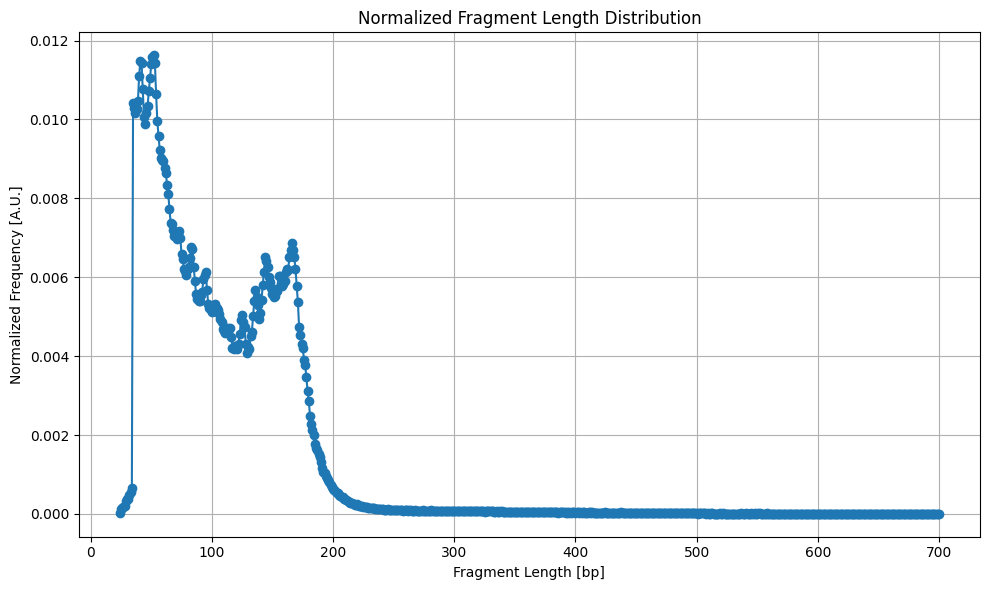

In [28]:
plt.figure(figsize=(10, 6))
plt.plot(normalized_freq.index, normalized_freq.values, marker='o')
plt.xlabel("Fragment Length [bp]")
plt.ylabel("Normalized Frequency [A.U.]")
plt.title("Normalized Fragment Length Distribution")
plt.grid(True)
plt.tight_layout()
plt.show()

**Read reference.hist File**                      
The reference file contains fragment lengths and their expected counts. We normalize them to create the reference distribution.

In [29]:
# Load reference histogram
reference_df = pd.read_csv("reference.hist", sep='\t', header=None, names=['length', 'count'])

# Normalize the reference distribution
reference_df['normalized'] = reference_df['count'] / reference_df['count'].sum()
reference_df.head()


,length,count,normalized
0,24,0.000013,0.000013
1,25,0.000063,0.000063
2,26,0.000092,0.000092
3,27,0.000117,0.000117
4,28,0.000136,0.000136


**Match Lengths Between Query and Reference**
We filter the reference to include only lengths also present in the query and align both distributions.

In [30]:
# Keep only lengths common to both datasets
common_lengths = reference_df['length'].isin(length_counts.index)
reference_df = reference_df[common_lengths]

# Align query normalized frequencies
query_common = normalized_freq.loc[reference_df['length']]


** Compute Rescaling Ratio**               
For each length, we compute the ratio of reference to query frequency. This tells us how much to downsample or retain.

In [31]:
# Compute the scaling ratio for each length
ratio = reference_df['normalized'].values / query_common.values
reference_df['ratio'] = ratio
reference_df.head()


,length,count,normalized,ratio
0,24,0.000013,0.000013,0.507866
1,25,0.000063,0.000063,0.546987
2,26,0.000092,0.000092,0.591484
3,27,0.000117,0.000117,0.636744
4,28,0.000136,0.000136,0.637451


**Resample the Query Data**                       
We use the computed ratio to subsample the query data so that its distribution resembles the reference.

In [32]:
# Resample based on ratio
rescaled_data = []

for length, r in zip(reference_df['length'], ratio):
    subset = df[df['length'] == length]
    sample_size = int(min(len(subset), len(subset) * r))
    if sample_size > 0:
        rescaled_data.append(subset.sample(n=sample_size, replace=False))

# Combine all resampled fragments
rescaled_df = pd.concat(rescaled_data)


**Plot Rescaled vs Reference Distribution**                           
We visualize how well the rescaled query distribution aligns with the reference.

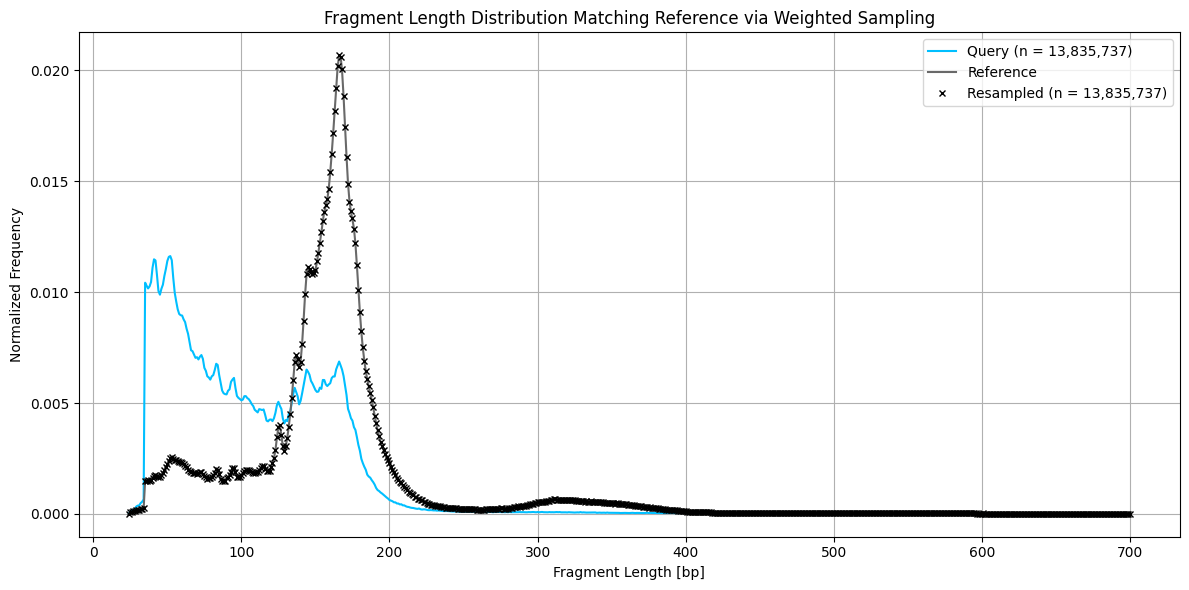

In [35]:
# Compute rescaled frequencies
rescaled_counts = rescaled_df['length'].value_counts().sort_index()
rescaled_freq = rescaled_counts / rescaled_counts.sum()

# Plot both distributions
plt.figure(figsize=(12, 6))
plot_distribution(query_freqs, f"Query (n = {total_query:,})", '-', 'deepskyblue')
plot_distribution(reference_probs, "Reference", 'None', 'dimgrey')
plot_distribution2(resampled_freqs, f"Resampled (n = {total_resampled:,})", 'None', 'black', marker='x')
plt.xlabel("Fragment Length [bp]")
plt.ylabel("Normalized Frequency")
plt.title("Fragment Length Distribution Matching Reference via Weighted Sampling")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()